In [1]:
"""
nombre: Jairo Blanco
codigo: 2024114040
materia: Inteligencia Artificial
tema: Machine Learning - Supervised Learning - ADALINE and Perceptron
"""

'\nnombre: Jairo Blanco\ncodigo: 2024114040\nmateria: Inteligencia Artificial\ntema: Machine Learning - Supervised Learning - ADALINE and Perceptron\n'

En este taller vamos a clasificar flores del dataset Iris con Perceptrón y Adaline (SGD). Todas las evaluaciones se hacen únicamente con accuracy_score.



In [2]:
from sklearn import datasets # cargamos la base de datos
from sklearn.linear_model import Perceptron, SGDRegressor # Perceptrón simple y Adaline (SGD con pérdida cuadrática)
from sklearn.model_selection import train_test_split # separamos la base de datos en 80-20
from sklearn.preprocessing import StandardScaler # estandarizamos los valores
from sklearn.metrics import accuracy_score # única métrica permitida en el taller
import matplotlib.pyplot as plt # gráficas
import numpy as np # matemáticas
import pandas as pd # tablas comparativas
from mlxtend.plotting import plot_decision_regions # fronteras de decisión

Cargamos el dataset completo. Las etiquetas son 0 = setosa, 1 = versicolor, 2 = virginica; y las columnas son 0 = sépalo largo, 1 = sépalo ancho, 2 = pétalo largo, 3 = pétalo ancho.

In [3]:
iris = datasets.load_iris() # cargamos nuestro dataset de flores
X_full = iris.data # los 4 features de las 150 flores
y_full = iris.target # las etiquetas de las 3 especies

print("Forma de X:", X_full.shape)
print("Clases:", iris.target_names)

Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']


# Pregunta 1. Clasificación binaria con Perceptrón

a) Cargamos y preparamos los datos: solo setosa y versicolor, y solo longitud y anchura del pétalo.

In [4]:
X = X_full[:,[2,3]] # sacamos los features del pétalo (largo y ancho)
y = y_full # etiquetas completas, necesitamos quitar una especie

mask = y<2 # segmentamos las 2 etiquetas que necesitamos: solo 0's (setosa) y 1's (versicolor)
X = X[mask]
y = y[mask]

print("Forma de X:", X.shape)
print("Muestras por clase:", np.bincount(y)) #esta función nos permite ver cuantos registros tenemos por clase, es de numpy :D

Forma de X: (100, 2)
Muestras por clase: [50 50]


b) Graficamos las dos clases para ver si se pueden separar con una recta.

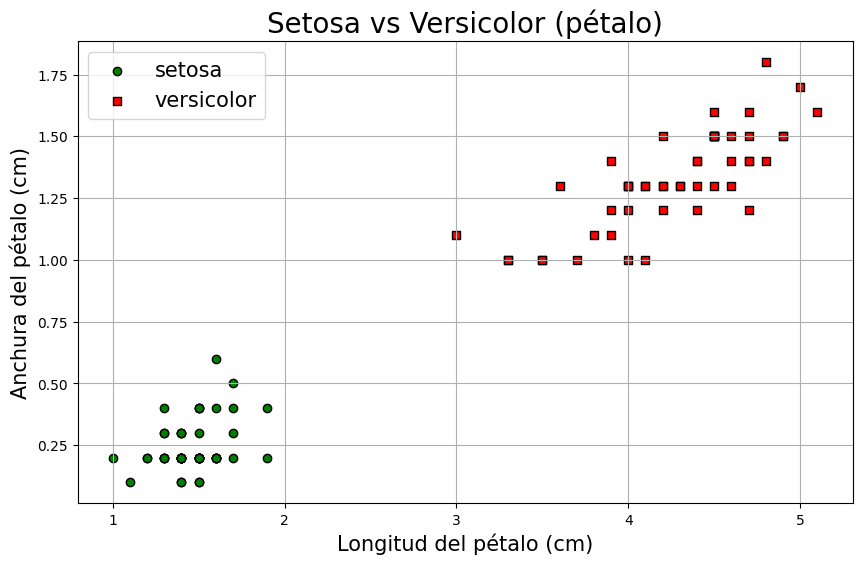

In [5]:
plt.figure(figsize=(10,6)) # base para las figuras que representan a los registros
plt.scatter(X[y==0,0],X[y==0,1],marker = "o",color = "green", edgecolors = "black", label = "setosa") # registros etiquetados como setosa
plt.scatter(X[y==1,0],X[y==1,1],marker = "s",color = "red", edgecolors = "black", label = "versicolor") # registros etiquetados como versicolor

plt.title("Setosa vs Versicolor (pétalo)", fontsize = 20)
plt.xlabel("Longitud del pétalo (cm)", fontsize = 15)
plt.ylabel("Anchura del pétalo (cm)", fontsize = 15)
plt.legend(loc = "best", fontsize = 15)
plt.grid(True)
plt.show()

c) Dividimos los datos en train y test (80/20).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, # dividimos el dataset en 80/20
                                                    train_size = 0.8,
                                                    test_size = 0.2,
                                                    random_state = 42, # semilla del taller para que sea reproducible
                                                    stratify = y, # mantiene la proporción de clases
                                                    shuffle = True)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape) #como son 100 registros en total, 80 serán para entrenar y dejamos 20 para realizar validaciones

Entrenamiento: (80, 2) | Prueba: (20, 2)


d) Llamamos al modelo y lo entrenamos con η = 0.01 , max_iter = 1000 y random_state = 42 - PERCEPTRON

In [7]:
percep_1 = Perceptron(max_iter = 1000, eta0 = 0.01, random_state = 42, verbose = 1) # épocas máximas, factor de aprendizaje y verbose para ver el aprendizaje época a época
percep_1.fit(X_train, y_train) # entrenamos el modelo

print("Épocas realizadas (n_iter_):", percep_1.n_iter_)

-- Epoch 1
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 80, Avg. loss: 0.002991
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 160, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 240, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 320, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 400, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 480, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.02, NNZs: 2, Bias: -0.030000, T: 560, Avg. loss: 0.000000
Total training time: 0.00 seconds.
Convergence after 7 epochs took 0.00 seconds
Épocas realizadas (n_iter_): 7


Mostramos visualmente el modelo con su frontera de decisión.

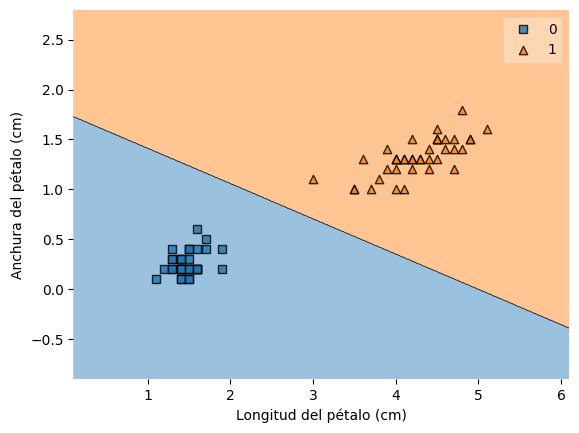

In [8]:
plot_decision_regions(X_train, y_train, clf = percep_1) # frontera sobre los datos de entrenamiento
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Anchura del pétalo (cm)")
plt.show()

e) Calculamos el accuracy en entrenamiento y prueba.

In [9]:
y_pred_train = percep_1.predict(X_train) # predicciones sobre lo que ya vio el modelo
y_pred_test = percep_1.predict(X_test) # predicciones sobre datos nuevos

print("Accuracy entrenamiento: %.2f" % accuracy_score(y_train, y_pred_train))
print("Accuracy prueba: %.2f" % accuracy_score(y_test, y_pred_test))

Accuracy entrenamiento: 1.00
Accuracy prueba: 1.00


**Interpretación.** El accuracy es 1.00 tanto en entrenamiento como en prueba, y el Perceptrón converge en solo 7 épocas. Setosa y versicolor son linealmente separables en el plano del pétalo (la dispersión muestra dos nubes bien separadas), y el Perceptrón garantiza encontrar un hiperplano separador cuando los datos son separables. Como ambos accuracies coinciden, no hay sobreajuste y el modelo generaliza bien. Con solo 20 muestras de prueba, el 1.00 se debe sobre todo a la separabilidad del problema y no es una garantía general.

# Pregunta 2. Influencia de la tasa de aprendizaje

Con los mismos datos y la misma partición de la pregunta 1, entrenamos tres Perceptrones con eta0 = 0.0001, 0.01 y 0.1, manteniendo max_iter=1000, tol=1e-3 y random_state=42. Guardamos el accuracy de prueba y las épocas de cada uno.

In [10]:
tasas = [0.0001, 0.01, 0.1] # las 3 tasas de aprendizaje que pide el taller
resultados = [] # aquí guardamos una fila por modelo

for eta in tasas:
    modelo = Perceptron(max_iter = 1000, tol = 1e-3, eta0 = eta, random_state = 42) # solo cambia eta0
    modelo.fit(X_train, y_train) # entrenamos con la misma partición

    acc = accuracy_score(y_test, modelo.predict(X_test)) # accuracy de prueba
    resultados.append({"Tasa de aprendizaje (eta0)": eta,
                       "Accuracy (prueba)": acc,
                       "Épocas (n_iter_)": modelo.n_iter_}) # épocas que necesitó para converger

d) Tabla comparativa.

In [11]:
tabla_2 = pd.DataFrame(resultados) #guardamos la lista en un dataframe para mostrarlo
display(tabla_2)

,Tasa de aprendizaje (eta0),Accuracy (prueba),Épocas (n_iter_)
0,0.0001,1.0,6
1,0.0100,1.0,7
2,0.1000,1.0,7


e) ¿Qué configuración funcionó mejor y por qué?

**Análisis.** Los tres modelos alcanzan accuracy de prueba 1.00, así que en precisión no hay diferencia. Sí hay una pequeña diferencia en épocas: eta0=0.0001 converge en 6 y eta0=0.01 y 0.1 en 7. Esto se explica porque los pesos arrancan en cero y la regla del Perceptrón es w ← w + η(y − ŷ)x: la tasa solo escala los pesos y no cambia el signo de w·x + b, por lo que la frontera resultante es la misma. La mejor configuración es eta0=0.0001, que logra el mismo accuracy con menos épocas, aunque la diferencia (6 vs. 7) es mínima y no es relevante en la práctica. La conclusión es que, con datos linealmente separables y pesos iniciales en cero, el Perceptrón es poco sensible a eta0.

# Pregunta 3. Adaline con SGD

a) Ahora usamos versicolor y virginica, con los features del pétalo, y convertimos las etiquetas a -1 y +1.

In [12]:
X = X_full[:,[2,3]] # features del pétalo
y = y_full # etiquetas completas

mask = y>0 # nos quedamos con 1's (versicolor) y 2's (virginica)
X = X[mask]
y = y[mask]

y = np.where(y==1, -1, 1) # versicolor -> -1, virginica -> +1

print("Valores de y:", np.unique(y))
print("Muestras por clase (-1, +1):", np.bincount((y+1)//2))

Valores de y: [-1  1]
Muestras por clase (-1, +1): [50 50]


Dividimos en train y test (80/20). Esta misma partición la vamos a reutilizar en la pregunta 4.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, # 80/20
                                                    train_size = 0.8,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y,
                                                    shuffle = True)

b) Estandarizamos con StandardScaler. El fit se hace SOLO con los datos de entrenamiento, para que el conjunto de prueba no le "cuente" nada al escalador.

In [14]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train) # fit solo con entrenamiento
X_test_std = sc.transform(X_test) # en prueba solo transform

c) Entrenamos Adaline con SGDRegressor: pérdida cuadrática, sin regularización, η=0.01, max_iter=1000 y random_state=42. Fijamos learning_rate="constant" para que eta0 sea de verdad la tasa de Adaline (por defecto sklearn la va reduciendo con las épocas).

In [15]:
adaline = SGDRegressor(loss = "squared_error", # pérdida cuadrática (regla delta de Adaline)
                       penalty = None, # sin regularización
                       learning_rate = "constant", # tasa fija igual a eta0
                       eta0 = 0.01,
                       max_iter = 1000,
                       random_state = 42)
adaline.fit(X_train_std, y_train) # entrenamos el modelo

print("Pesos:", adaline.coef_)
print("Bias:", adaline.intercept_)

Pesos: [0.29935707 0.59255276]
Bias: [0.00528861]


d) La salida de Adaline es continua, así que la pasamos a clases: mayor o igual a 0 es +1 y menor que 0 es -1.

In [16]:
salida_train = adaline.predict(X_train_std) # valores continuos
salida_test = adaline.predict(X_test_std)

y_pred_train_ada = np.where(salida_train >= 0, 1, -1) # umbral en 0
y_pred_test_ada = np.where(salida_test >= 0, 1, -1)

print("Primeras 5 salidas continuas:", salida_test[:5].round(3))
print("Primeras 5 clases predichas:", y_pred_test_ada[:5])

Primeras 5 salidas continuas: [ 0.637  0.122  0.429  0.331 -1.546]
Primeras 5 clases predichas: [ 1  1  1  1 -1]


e) Calculamos el accuracy en entrenamiento y prueba.

In [17]:
print("Accuracy entrenamiento (Adaline): %.3f" % accuracy_score(y_train, y_pred_train_ada))
print("Accuracy prueba (Adaline): %.2f" % accuracy_score(y_test, y_pred_test_ada))

Accuracy entrenamiento (Adaline): 0.975
Accuracy prueba (Adaline): 0.80


**Interpretación.** Adaline obtiene 0.975 en entrenamiento y 0.80 en prueba. La brecha indica que versicolor y virginica no son perfectamente separables con una recta: hay una zona de solapamiento y el modelo falla en algunos puntos de prueba. Además, con 20 muestras de prueba cada error vale 0.05, por lo que la diferencia entre ambos accuracies es sensible a cómo cayó la partición.

# Pregunta 4. Comparación entre Perceptrón y Adaline

a), b) Usamos la misma partición (X_train_std, X_test_std) para los dos modelos. Adaline ya está entrenado, así que entrenamos el Perceptrón.

In [19]:
percep_4 = Perceptron(max_iter = 1000, eta0 = 0.01, random_state = 42, verbose=True) # mismos hiperparámetros que antes
percep_4.fit(X_train_std, y_train) # entrenamos con los mismos datos que Adaline

-- Epoch 1
Norm: 0.02, NNZs: 2, Bias: 0.010000, T: 80, Avg. loss: 0.000141
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.03, NNZs: 2, Bias: 0.010000, T: 160, Avg. loss: 0.000240
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.03, NNZs: 2, Bias: 0.000000, T: 240, Avg. loss: 0.000040
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.03, NNZs: 2, Bias: 0.000000, T: 320, Avg. loss: 0.000238
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.03, NNZs: 2, Bias: 0.010000, T: 400, Avg. loss: 0.000180
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.03, NNZs: 2, Bias: 0.000000, T: 480, Avg. loss: 0.000351
Total training time: 0.00 seconds.
Convergence after 6 epochs took 0.00 seconds


Perceptron(eta0=0.01, random_state=42, verbose=True)

c) Accuracy de entrenamiento y prueba de ambos algoritmos.

In [20]:
y_pred_train_per = percep_4.predict(X_train_std) # el Perceptrón ya devuelve -1 / +1
y_pred_test_per = percep_4.predict(X_test_std)

tabla_4 = pd.DataFrame({
    "Modelo": ["Perceptrón", "Adaline (SGD)"],
    "Accuracy entrenamiento": [accuracy_score(y_train, y_pred_train_per),
                               accuracy_score(y_train, y_pred_train_ada)],
    "Accuracy prueba": [accuracy_score(y_test, y_pred_test_per),
                        accuracy_score(y_test, y_pred_test_ada)]
})
display(tabla_4)

,Modelo,Accuracy entrenamiento,Accuracy prueba
0,Perceptrón,0.975,0.85
1,Adaline (SGD),0.975,0.80


d) Frontera de decisión de cada modelo en una gráfica independiente. mlxtend necesita un modelo con predict que devuelva clases enteras, así que usamos un envoltorio que aplica el umbral en 0 (sirve para ambos modelos), y pasamos las etiquetas a 0/1 solo para graficar.

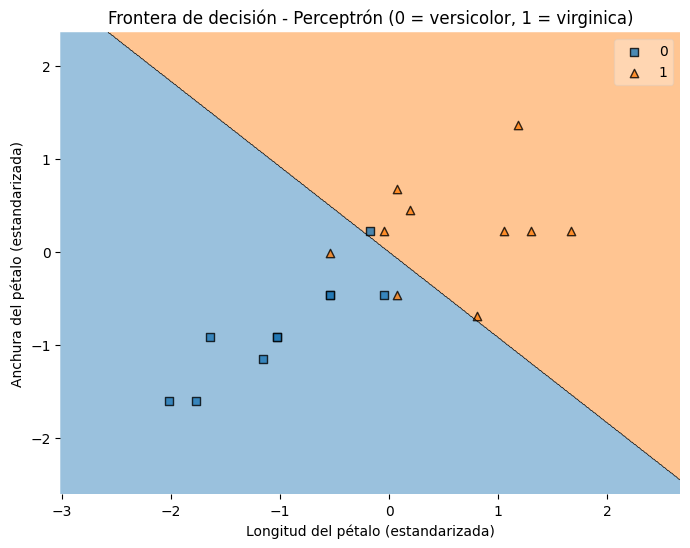

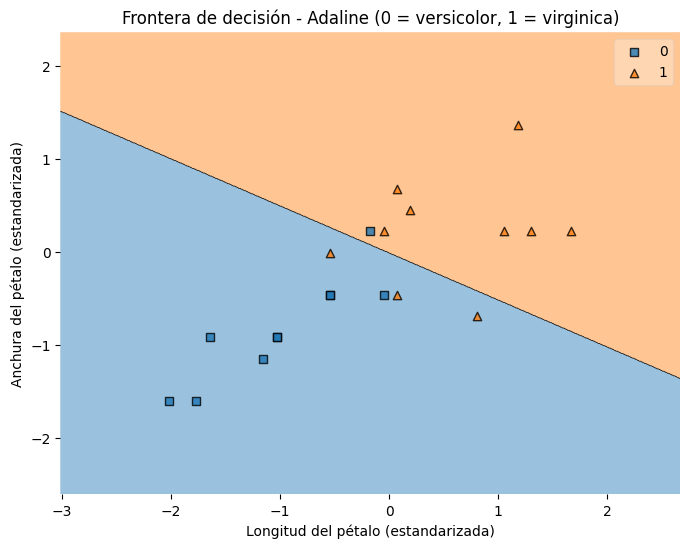

In [21]:
class ModeloBinario: # envoltorio para que mlxtend pueda graficar a Perceptrón y a Adaline
    def __init__(self, modelo):
        self.modelo = modelo
    def predict(self, X):
        return (self.modelo.predict(X) >= 0).astype(int) # umbral en 0 -> clases 0/1

y_train_plot = (y_train > 0).astype(int) # -1/+1 -> 0/1 solo para graficar
y_test_plot = (y_test > 0).astype(int)

plt.figure(figsize=(8,6))
plot_decision_regions(X_test_std, y_test_plot, clf = ModeloBinario(percep_4)) # frontera del Perceptrón
plt.title("Frontera de decisión - Perceptrón (0 = versicolor, 1 = virginica)")
plt.xlabel("Longitud del pétalo (estandarizada)")
plt.ylabel("Anchura del pétalo (estandarizada)")
plt.show()

plt.figure(figsize=(8,6))
plot_decision_regions(X_test_std, y_test_plot, clf = ModeloBinario(adaline)) # frontera de Adaline
plt.title("Frontera de decisión - Adaline (0 = versicolor, 1 = virginica)")
plt.xlabel("Longitud del pétalo (estandarizada)")
plt.ylabel("Anchura del pétalo (estandarizada)")
plt.show()

e) Comparación y diferencias observadas.

**Análisis.** Ambos modelos tienen 0.975 de accuracy en entrenamiento. En prueba el Perceptrón obtiene 0.85 y Adaline 0.80, es decir, un solo acierto más del Perceptrón entre 20 muestras, una diferencia que puede deberse al azar de la partición y no a una superioridad real. Las diferencias de fondo son de método: el Perceptrón actualiza los pesos solo cuando clasifica mal una muestra (error de clasificación), y si los datos no son separables no converge y su frontera puede oscilar según el orden de las muestras. Adaline minimiza el error cuadrático sobre la salida continua (regla delta), que es una función convexa y produce una frontera más estable, aunque no optimiza directamente el accuracy. Como versicolor y virginica se solapan, ambas fronteras son rectas parecidas que dejan algunos puntos del lado equivocado.

# Pregunta 5. Clasificación de las tres especies de Iris

a) Usamos las tres clases y las cuatro características (sin máscara), y dividimos en train y test (80/20).

In [22]:
X = X_full # los 4 features
y = y_full # las 3 clases

X_train, X_test, y_train, y_test = train_test_split(X, y, # 80/20
                                                    train_size = 0.8,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y,
                                                    shuffle = True)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (120, 4) | Prueba: (30, 4)


b) Estandarizamos las cuatro características y entrenamos un Perceptrón multiclase (sklearn lo resuelve con uno-contra-todos: un Perceptrón binario por clase).

In [24]:
sc_4var = StandardScaler()
X_train_std = sc_4var.fit_transform(X_train) # fit solo con entrenamiento
X_test_std = sc_4var.transform(X_test)

percep_4var = Perceptron(max_iter = 1000, eta0 = 0.01, random_state = 42, verbose=True)
percep_4var.fit(X_train_std, y_train) # entrenamos con las 4 variables

-- Epoch 1
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 120, Avg. loss: 0.000092
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 240, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 360, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 480, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 600, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.03, NNZs: 4, Bias: -0.010000, T: 720, Avg. loss: 0.000000
Total training time: 0.00 seconds.
Convergence after 6 epochs took 0.00 seconds
-- Epoch 1
Norm: 0.03, NNZs: 4, Bias: 0.000000, T: 120, Avg. loss: 0.007759
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.05, NNZs: 4, Bias: -0.010000, T: 240, Avg. loss: 0.005643
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.06, NNZs: 4, Bias: -0.030000, T: 360, Avg

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Perceptron(eta0=0.01, random_state=42, verbose=True)

c) Accuracy en el conjunto de prueba (4 variables).

In [25]:
acc_4var = accuracy_score(y_test, percep_4var.predict(X_test_std))
print("Accuracy prueba (4 variables): %.2f" % acc_4var)

Accuracy prueba (4 variables): 0.90


d) Segundo Perceptrón usando solo longitud y anchura del pétalo, con su propio StandardScaler (también ajustado solo con entrenamiento).

In [26]:
sc_2var = StandardScaler()
X_train_2var = sc_2var.fit_transform(X_train[:,[2,3]]) # solo columnas del pétalo
X_test_2var = sc_2var.transform(X_test[:,[2,3]])

percep_2var = Perceptron(max_iter = 1000, eta0 = 0.01, random_state = 42)
percep_2var.fit(X_train_2var, y_train)

acc_2var = accuracy_score(y_test, percep_2var.predict(X_test_2var))
print("Accuracy prueba (2 variables del pétalo): %.2f" % acc_2var)

Accuracy prueba (2 variables del pétalo): 0.73


e) Comparamos los dos modelos.

In [27]:
tabla_5 = pd.DataFrame({
    "Modelo": ["Perceptrón (4 variables)", "Perceptrón (pétalo)"],
    "Accuracy prueba": [acc_4var, acc_2var]
})
display(tabla_5)

,Modelo,Accuracy prueba
0,Perceptrón (4 variables),0.900000
1,Perceptrón (pétalo),0.733333


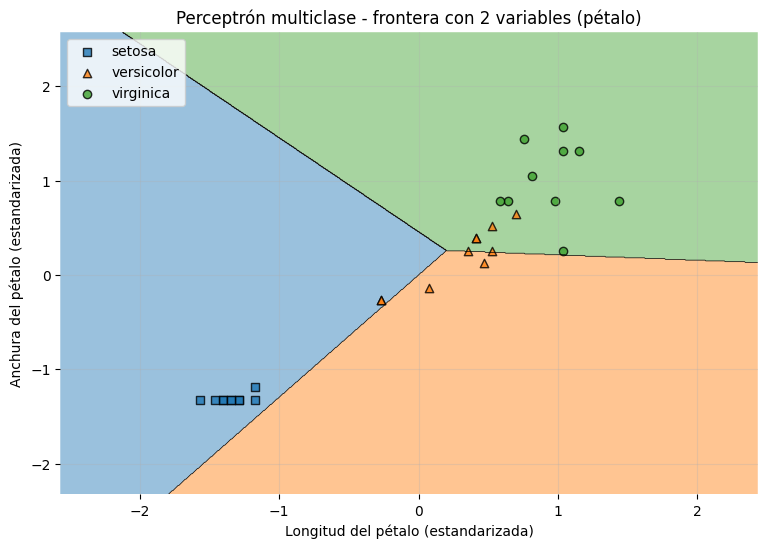

In [29]:
plt.figure(figsize=(9,6))
plot_decision_regions(X_test_2var, y_test, clf = percep_2var) # regiones de las 3 especies sobre datos de prueba
plt.title("Perceptrón multiclase - frontera con 2 variables (pétalo)")
plt.xlabel("Longitud del pétalo (estandarizada)")
plt.ylabel("Anchura del pétalo (estandarizada)")
plt.legend(["setosa", "versicolor", "virginica"], loc = "upper left") # 0, 1, 2
plt.grid(True, alpha = 0.3)
plt.show()